In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Percorso della cartella principale su Google Drive
base_path = "/content/drive/MyDrive/MLHD_Project"

In [3]:
import numpy as np
from tensorflow.keras.models import load_model

# Carica i pesi del modello
model_path = f"{base_path}/posture_cnn_model.h5"
model = load_model(model_path)

# Carica i file di test
X_test_path = f"{base_path}/X_test_small.npy"
y_test_path = f"{base_path}/y_test_small.npy"

X_test = np.load(X_test_path)
y_test = np.load(y_test_path)

In [4]:
class_names = {
    0: 'Supine',
    1: 'Right',
    2: 'Left',
    3: 'Right, body-roll 30°',
    4: 'Right, body-roll 60°',
    5: 'Left, body-roll 30°',
    6: 'Left, body-roll 60°',
    7: 'Supine, "star"',
    8: 'Supine, "straight"',
    9: 'Supine, "bent legs"',
    10: 'Supine, "left arm up"',
    11: 'Supine, "right arm up"',
    12: 'Right fetus',
    13: 'Left fetus',
    14: 'Supine, bed inclination 30°',
    15: 'Supine, bed inclination 45°',
    16: 'Supine, bed inclination 60°',
    17: 'Sensor detection error'
}

In [5]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

#load the model

def show_prediction(index):
    image = X_test[index]
    true_label = np.argmax(y_test[index])
    prediction = model.predict(image[np.newaxis, ...])
    pred_label = np.argmax(prediction)

    plt.imshow(image[:, :, 0], cmap='gray')
    plt.title(f"True: {class_names[true_label]} | Pred: {class_names[pred_label]}")
    plt.axis('off')
    plt.show()

slider = widgets.IntSlider(min=0, max=len(X_test)-1, step=1, description='Index_image') #max=len(X_test)-1
widgets.interact(show_prediction, index=slider)

print('Data collected using Vista Medical FSA SoftFlex 2048')

#Right and left are the opposite in all dataset



interactive(children=(IntSlider(value=0, description='Index_image', max=99), Output()), _dom_classes=('widget-…

Data collected using Vista Medical FSA SoftFlex 2048


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


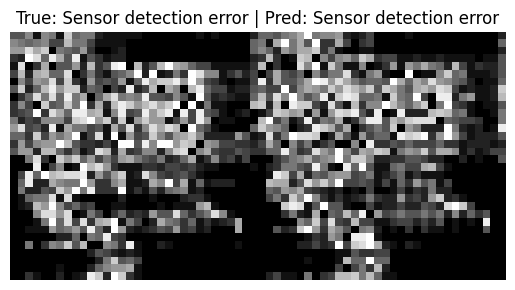

In [26]:
show_prediction(60)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


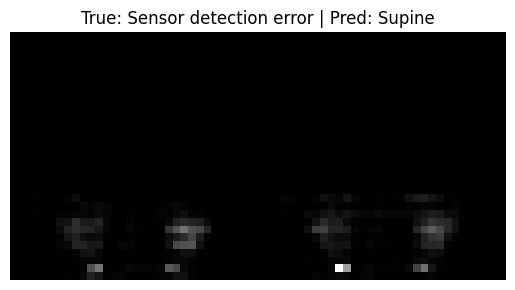

In [30]:
show_prediction(58)